# Generated compounds in the training chemical space

Compare a **full export of generated molecules** and the **top-N most active** compounds against the HDAC8 training set.

- Input: molecules CSV export (e.g. `2026-08-31T16-18_export.csv`)
- Embedding: **UMAP only** (Jaccard on ECFP4 fingerprints)
- Similarity: nearest-neighbour Tanimoto vs training set


In [36]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from rdkit import Chem, RDLogger
from rdkit.Chem import DataStructs, Draw
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
from rdkit.Chem.Scaffolds import MurckoScaffold
import umap

RDLogger.DisableLog("rdApp.*")
warnings.filterwarnings("ignore")

SEED = 42
FP_RADIUS = 2
FP_SIZE = 2048
TC_CLOSE = 0.85
TC_MODERATE = 0.50

TRAIN_SDF = Path("HDAC8_train.sdf")
GEN_CSV = Path("The prioritized generated compounds.csv")
OUT_DIR = Path("chemical_space_outputs")
OUT_DIR.mkdir(exist_ok=True)

TOP_N = 3  # number of most active compounds for the focused analysis

sns.set_theme(style="whitegrid", context="talk")


## 1. Data loading

Training molecules: `HDAC8_train.sdf`. Generated molecules: CSV export with a SMILES column (`canonical_smiles`, `generated_smiles`, or `smiles`).


In [37]:
def load_train_sdf(path):
    supplier = Chem.ForwardSDMolSupplier(str(path), sanitize=False)
    rows, failed = [], []
    for i, mol in enumerate(supplier):
        rec = {"train_index": i + 1}
        if mol is None:
            failed.append({**rec, "reason": "unreadable record"})
            continue
        rec["chembl_id"] = (
            mol.GetProp("molecule_chembl_id")
            if mol.HasProp("molecule_chembl_id")
            else f"mol_{i+1}"
        )
        rec["pchembl"] = (
            float(mol.GetProp("pchembl_value_mean"))
            if mol.HasProp("pchembl_value_mean")
            else np.nan
        )
        try:
            Chem.SanitizeMol(mol)
            smiles = Chem.MolToSmiles(mol)
            std_mol = Chem.MolFromSmiles(smiles)
            if std_mol is None:
                raise ValueError("MolFromSmiles returned None")
        except Exception as exc:
            failed.append({**rec, "reason": str(exc)})
            continue
        rec.update({"mol": std_mol, "smiles": Chem.MolToSmiles(std_mol)})
        rows.append(rec)
    data = pd.DataFrame(rows)
    failed = pd.DataFrame(failed)
    print(f"{path.name}: kept {len(data)} / {len(data) + len(failed)} molecules ({len(failed)} failed)")
    return data, failed


def _read_generated_table(path):
    path = Path(path)
    last_exc = None
    for sep in (";", ",", "\t"):
        try:
            df = pd.read_csv(path, sep=sep)
            if len(df.columns) > 1:
                return df
        except Exception as exc:
            last_exc = exc
    raise ValueError(f"Could not parse {path.name} as CSV/TSV: {last_exc}")


def _find_smiles_column(df):
    normalized = {str(c).strip().lower(): c for c in df.columns}
    for key in ("canonical_smiles", "generated_smiles", "smiles", "ligand_smiles", "ligand smiles"):
        if key in normalized:
            return normalized[key]
    return None


def _looks_like_summary_export(df):
    cols = [str(c).strip().lower() for c in df.columns]
    if cols and cols[0] == "metric":
        return True
    return "total generated structures" in df.iloc[:, 0].astype(str).str.lower().values


def load_generated(path):
    path = Path(path)
    df = _read_generated_table(path)
    if _looks_like_summary_export(df):
        raise ValueError(
            f"{path.name} looks like a summary/metrics export, not a molecules table. "
            "Use a molecules export with SMILES columns."
        )
    smiles_col = _find_smiles_column(df)
    if smiles_col is None:
        raise ValueError(
            f"No SMILES column found in {path.name}. Available columns: {list(df.columns)}"
        )
    rows, failed = [], []
    for i, row in df.iterrows():
        rec = row.to_dict()
        rec["gen_index"] = int(row["No."]) if "No." in row else i + 1
        smi = str(row[smiles_col]).strip()
        if not smi or smi.lower() in {"nan", "none"}:
            failed.append({**rec, "reason": "empty SMILES"})
            continue
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            failed.append({**rec, "reason": "invalid SMILES"})
            continue
        rec["mol"] = mol
        rec["smiles"] = Chem.MolToSmiles(mol)
        if "canonical_smiles" not in rec:
            rec["canonical_smiles"] = rec["smiles"]
        rows.append(rec)
    data = pd.DataFrame(rows)
    failed = pd.DataFrame(failed)
    print(
        f"{path.name}: kept {len(data)} / {len(data) + len(failed)} molecules "
        f"({len(failed)} failed); SMILES column: {smiles_col!r}"
    )
    return data, failed


train_df, train_failed = load_train_sdf(TRAIN_SDF)
gen_df, gen_failed = load_generated(GEN_CSV)

display(train_failed if len(train_failed) else "No failed training molecules")
display(gen_failed if len(gen_failed) else "No failed generated molecules")

if "predicted_pIC50" not in gen_df.columns:
    raise ValueError("Column 'predicted_pIC50' is required to rank the top active compounds.")

gen_df["predicted_pIC50"] = pd.to_numeric(gen_df["predicted_pIC50"], errors="coerce")
gen_df = gen_df.sort_values("predicted_pIC50", ascending=False).reset_index(drop=True)

train_smi_set = set(train_df["smiles"])
top_df = gen_df.head(TOP_N).copy()

print(f"Generated set: {len(gen_df)} compounds")
print(
    f"Predicted pIC50 (full set): {gen_df['predicted_pIC50'].mean():.3f} ± "
    f"{gen_df['predicted_pIC50'].std():.3f} "
    f"[{gen_df['predicted_pIC50'].min():.2f}, {gen_df['predicted_pIC50'].max():.2f}]"
)
print(f"Top {TOP_N} predicted pIC50 range: {top_df['predicted_pIC50'].min():.3f} – {top_df['predicted_pIC50'].max():.3f}")
display(top_df[["No.", "canonical_smiles", "predicted_pIC50", "SAScore", "in_AD"]].head(TOP_N))


HDAC8_train.sdf: kept 2092 / 2092 molecules (0 failed)
The prioritized generated compounds.csv: kept 500 / 500 molecules (0 failed); SMILES column: 'canonical_smiles'


'No failed training molecules'

'No failed generated molecules'

Generated set: 500 compounds
Predicted pIC50 (full set): 6.662 ± 0.118 [6.54, 7.27]
Top 3 predicted pIC50 range: 7.237 – 7.269


,No.,canonical_smiles,predicted_pIC50,SAScore,in_AD
0,1,O=C(NO)c1cccc(NS(=O)(=O)c2ccccc2)c1,7.2693,1.728,True
1,2,O=C(NO)c1ccc(NC(=O)c2ccc(Br)cc2Br)cc1,7.2443,1.874,True
2,3,O=C(NO)c1ccc(NC(=O)c2cc(Br)cc(Br)c2F)cc1,7.2368,2.132,True


## 2. Fingerprints, nearest neighbours and UMAP

ECFP4 fingerprints are computed once for the training set. UMAP is fitted on training fingerprints (Jaccard metric) and reused for every query subset.


In [38]:
morgan_gen = GetMorganGenerator(radius=FP_RADIUS, fpSize=FP_SIZE)


def get_fps(mols):
    return [morgan_gen.GetFingerprint(mol) for mol in mols]


def fps_to_array(fps, n_bits=FP_SIZE):
    X = np.zeros((len(fps), n_bits), dtype=np.float64)
    for i, fp in enumerate(fps):
        DataStructs.ConvertToNumpyArray(fp, X[i])
    return X


def _gen_metadata(row):
    muegge = row["Muegge rules"] if "Muegge rules" in row.index else row.get("Muegge_rules", np.nan)
    return {
        "predicted_pIC50": row.get("predicted_pIC50", np.nan),
        "SAScore": row.get("SAScore", np.nan),
        "in_AD": row.get("in_AD", np.nan),
        "Muegge_rules": muegge,
    }


def compute_nearest_neighbours(gen_df, train_df, train_fps, train_smi_set):
    gen_fps = get_fps(gen_df["mol"].tolist())
    nn_rows = []
    max_tc = np.empty(len(gen_df), dtype=np.float64)
    for i, gen_fp in enumerate(gen_fps):
        sims = np.asarray(DataStructs.BulkTanimotoSimilarity(gen_fp, train_fps), dtype=np.float64)
        j = int(np.argmax(sims))
        max_tc[i] = sims[j]
        meta = _gen_metadata(gen_df.iloc[i])
        rec = {
            "No.": gen_df.iloc[i]["gen_index"],
            "canonical_smiles": gen_df.iloc[i]["smiles"],
            **meta,
            "exact_match_in_train": gen_df.iloc[i]["smiles"] in train_smi_set,
            "max_Tc": max_tc[i],
            "nn1_chembl_id": train_df.iloc[j]["chembl_id"],
            "nn1_smiles": train_df.iloc[j]["smiles"],
            "nn1_pchembl": train_df.iloc[j]["pchembl"],
            "nn1_Tc": sims[j],
        }
        rec["interpolation_class"] = (
            "close analogue (Tc >= 0.85)"
            if max_tc[i] >= TC_CLOSE
            else ("related (0.50 <= Tc < 0.85)" if max_tc[i] >= TC_MODERATE else "distant (Tc < 0.50)")
        )
        nn_rows.append(rec)
    nn_df = pd.DataFrame(nn_rows)
    gen_df = gen_df.assign(max_Tc=max_tc, interpolation_class=nn_df["interpolation_class"].values)
    return gen_df, nn_df, gen_fps


def count_ge(arr, thr):
    return int(np.sum(arr >= thr))


train_fps = get_fps(train_df["mol"].tolist())
X_train = fps_to_array(train_fps)
print(f"Training fingerprints: {len(train_fps)} molecules")

print("Fitting UMAP on the training set (Jaccard metric; may take ~1-2 min)...")
umap_reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.3,
    metric="jaccard",
    random_state=SEED,
)
train_umap = umap_reducer.fit_transform(X_train)
print("UMAP fit complete.")


Training fingerprints: 2092 molecules
Fitting UMAP on the training set (Jaccard metric; may take ~1-2 min)...
UMAP fit complete.


## 3. Analysis helpers

Statistics, export and manuscript figures (Tanimoto histogram + combined UMAP). **PCA is not used.**



In [ ]:
def _safe_slug(name):
    slug = "".join(ch if ch.isalnum() or ch in "-_" else "_" for ch in str(name).strip())
    return slug or "set"

# Scaffold function — exact copy from HDAC8_scaffold_similarity_analysis.ipynb
# (no 'if smiles' guard; None appended on any failure).
def get_bemis_murcko_scaffolds(mols):
    """Return (unique_scaffold_smiles_set, list_per_mol). Mirrors HDAC8_scaffold_similarity_analysis.ipynb."""
    scaffolds = set()
    scaffold_list = []
    for mol in mols:
        try:
            scaffold = MurckoScaffold.GetScaffoldForMol(mol)
            smiles = Chem.MolToSmiles(scaffold)
            scaffolds.add(smiles)
            scaffold_list.append(smiles)
        except Exception:
            scaffold_list.append(None)
    return scaffolds, scaffold_list


# Compute training scaffolds ONCE — same pipeline as HDAC8_scaffold_similarity_analysis.ipynb:
# SDMolSupplier(sanitize=True, default), filter None → get_bemis_murcko_scaffolds.
# This yields 1131 unique scaffolds, consistent across both notebooks.
_train_suppl_std = Chem.SDMolSupplier(str(TRAIN_SDF))
_train_mols_std = [m for m in _train_suppl_std if m is not None]
train_scaffolds_global, _ = get_bemis_murcko_scaffolds(_train_mols_std)
print(f"Training scaffolds (SDMolSupplier, sanitize=True): {len(train_scaffolds_global)} unique")


def analyze_compound_set(
    gen_df,
    *,
    set_label,
    file_prefix,
    show_structure_grid=False,
):
    """Compute NN statistics, export tables; optional structure grid."""
    if len(gen_df) == 0:
        raise ValueError("No valid structures to analyze.")

    gen_df, nn_df, gen_fps = compute_nearest_neighbours(
        gen_df, train_df, train_fps, train_smi_set
    )
    X_gen = fps_to_array(gen_fps)
    gen_umap = umap_reducer.transform(X_gen)

    n_gen = len(nn_df)
    mean_tc = float(nn_df["max_Tc"].mean())
    std_tc = float(nn_df["max_Tc"].std(ddof=1)) if n_gen > 1 else 0.0
    median_tc = float(nn_df["max_Tc"].median())
    q25, q75 = nn_df["max_Tc"].quantile([0.25, 0.75])
    min_tc, max_tc_val = float(nn_df["max_Tc"].min()), float(nn_df["max_Tc"].max())
    corr = float(nn_df["predicted_pIC50"].corr(nn_df["max_Tc"])) if n_gen > 1 else np.nan

    # Bemis-Murcko scaffold representation (domain-coverage proxy)
    # Use pre-computed train_scaffolds_global (SDMolSupplier, sanitize=True)
    # — consistent with HDAC8_scaffold_similarity_analysis.ipynb (1131 unique scaffolds)
    train_scaffolds = train_scaffolds_global
    gen_scaffolds, gen_scaff_list = get_bemis_murcko_scaffolds(gen_df["mol"].tolist())
    shared_scaffolds = train_scaffolds.intersection(gen_scaffolds)
    shared_scaffolds_pct_of_gen = (
        100.0 * len(shared_scaffolds) / len(gen_scaffolds) if len(gen_scaffolds) else 0.0
    )
    is_scaffold_in_train = [s in train_scaffolds for s in gen_scaff_list]
    shared_scaffold_mol_pct = (
        100.0 * float(np.mean(is_scaffold_in_train)) if len(is_scaffold_in_train) else 0.0
    )

    gen_df = gen_df.assign(
        Bemis_Murcko_scaffold=gen_scaff_list,
        Is_Scaffold_In_Train=is_scaffold_in_train,
    )
    nn_df = nn_df.assign(
        Bemis_Murcko_scaffold=gen_scaff_list,
        Is_Scaffold_In_Train=is_scaffold_in_train,
    )

    print("=" * 64)
    print(f"ANALYSIS: {set_label}")
    print("=" * 64)
    print(f"n compounds: {n_gen}")
    print(f"Mean max Tc:   {mean_tc:.4f} ± {std_tc:.4f}")
    print(f"Median max Tc: {median_tc:.4f}  (IQR {q25:.4f}–{q75:.4f})")
    print(f"Range:         [{min_tc:.4f}, {max_tc_val:.4f}]")
    print(f"Exact SMILES overlap with training set: {int(nn_df['exact_match_in_train'].sum())}")
    print(
        f"Bemis-Murcko scaffolds: train={len(train_scaffolds)}, generated={len(gen_scaffolds)}, "
        f"shared={len(shared_scaffolds)} ({shared_scaffolds_pct_of_gen:.1f}% of generated unique scaffolds)"
    )
    print(f"Shared-scaffold molecule coverage: {shared_scaffold_mol_pct:.1f}%")
    print(
        f"Predicted pIC50: {nn_df['predicted_pIC50'].mean():.3f} ± "
        f"{nn_df['predicted_pIC50'].std():.3f} "
        f"[{nn_df['predicted_pIC50'].min():.2f}, {nn_df['predicted_pIC50'].max():.2f}]"
    )
    print(f"Pearson r(predicted pIC50, max Tc) = {corr:.3f}")

    class_counts = (
        nn_df["interpolation_class"]
        .value_counts()
        .reindex(
            ["close analogue (Tc >= 0.85)", "related (0.50 <= Tc < 0.85)", "distant (Tc < 0.50)"],
            fill_value=0,
        )
        .rename_axis("class")
        .reset_index(name="n")
    )
    class_counts["percent"] = 100 * class_counts["n"] / n_gen
    display(class_counts.style.format({"percent": "{:.2f}"}).set_caption("Interpolation classes"))

    show_cols = [
        "No.", "canonical_smiles", "predicted_pIC50", "max_Tc",
        "interpolation_class", "nn1_chembl_id", "nn1_Tc", "nn1_pchembl", "nn1_smiles",
    ]
    nn_view = nn_df[show_cols].sort_values("predicted_pIC50", ascending=False).reset_index(drop=True)
    display(nn_view)

    scaffold_overlap_path = OUT_DIR / f"{file_prefix}_scaffold_overlap.csv"
    scaffold_cols = [
        "No.",
        "canonical_smiles",
        "predicted_pIC50",
        "max_Tc",
        "interpolation_class",
        "Bemis_Murcko_scaffold",
        "Is_Scaffold_In_Train",
    ]
    nn_df[scaffold_cols].to_csv(scaffold_overlap_path, index=False)

    # Plot: top scaffold frequencies (shared vs novel)
    scaffold_counts = nn_df["Bemis_Murcko_scaffold"].value_counts(dropna=False)
    top_k = min(12, len(scaffold_counts))
    top_counts = scaffold_counts.head(top_k)
    scaffold_in_train_map = {sc: (sc in train_scaffolds) for sc in top_counts.index}
    colors = ["#2ca02c" if scaffold_in_train_map[sc] else "#d9d9d9" for sc in top_counts.index]
    labels = [sc if sc is not None else "None" for sc in top_counts.index]
    short_labels = [lab if len(lab) <= 22 else lab[:22] + "..." for lab in labels]
    fig, ax = plt.subplots(figsize=(8, 6))
    y = np.arange(top_k)
    ax.barh(y, top_counts.values[::-1], color=colors[::-1])
    ax.set_yticks(y)
    ax.set_yticklabels(short_labels[::-1], fontsize=8)
    ax.invert_yaxis()
    ax.set_xlabel("Number of generated molecules")
    ax.set_title(
        f"Top {top_k} generated scaffolds (shared vs novel)\n"
        f"Shared unique scaffolds: {len(shared_scaffolds)}/{len(gen_scaffolds)}"
    )
    plt.tight_layout()
    scaffold_top_plot_path = OUT_DIR / f"{file_prefix}_top_scaffolds.png"
    fig.savefig(scaffold_top_plot_path, dpi=300, bbox_inches="tight")
    plt.show()

    # Plot: Tc distribution split by scaffold novelty
    plot_df = nn_df.copy()
    plot_df["scaffold_group"] = np.where(
        plot_df["Is_Scaffold_In_Train"],
        "Scaffold in training",
        "Novel scaffold",
    )
    bins = max(5, min(25, len(plot_df) // 10))
    fig, ax = plt.subplots(figsize=(7.2, 5.2))
    sns.histplot(
        data=plot_df,
        x="max_Tc",
        hue="scaffold_group",
        bins=bins,
        kde=True,
        edgecolor="black",
        ax=ax,
    )
    ax.axvline(TC_CLOSE, color="crimson", linestyle="--", linewidth=1.2)
    ax.axvline(TC_MODERATE, color="darkorange", linestyle="--", linewidth=1.2)
    ax.set_xlabel("Nearest-neighbour Tanimoto similarity ($T_c$)")
    ax.set_title("Scaffold novelty vs nearest-neighbour similarity")
    plt.tight_layout()
    scaffold_tc_plot_path = OUT_DIR / f"{file_prefix}_scaffold_novelty_vs_Tc.png"
    fig.savefig(scaffold_tc_plot_path, dpi=300, bbox_inches="tight")
    plt.show()

    if show_structure_grid:
        mols, legends = [], []
        for _, row in nn_view.iterrows():
            mols.append(Chem.MolFromSmiles(row["canonical_smiles"]))
            legends.append(
                f"#{int(row['No.'])} | pred {row['predicted_pIC50']:.2f} | Tc {row['max_Tc']:.2f}"
            )
            mols.append(Chem.MolFromSmiles(row["nn1_smiles"]))
            legends.append(
                f"NN {row['nn1_chembl_id']} | pChEMBL {row['nn1_pchembl']:.2f} | Tc {row['nn1_Tc']:.2f}"
            )
        img = Draw.MolsToGridImage(
            mols, molsPerRow=2, subImgSize=(280, 220), legends=legends, returnPNG=False
        )
        display(img)
        img.save(str(OUT_DIR / f"{file_prefix}_nn_example_pairs.png"))

    nn_path = OUT_DIR / f"{file_prefix}_nearest_neighbour_similarity.csv"
    summary_path = OUT_DIR / f"{file_prefix}_similarity_summary.csv"
    nn_df.to_csv(nn_path, index=False)
    summary = pd.DataFrame([{
        "set_label": set_label,
        "n_compounds": n_gen,
        "n_training": len(train_df),
        "Mean_Max_Tc": mean_tc,
        "Std_Max_Tc": std_tc,
        "Median_Max_Tc": median_tc,
        "Min_Max_Tc": min_tc,
        "Max_Max_Tc": max_tc_val,
        "Mean_predicted_pIC50": float(nn_df["predicted_pIC50"].mean()),
        "Max_predicted_pIC50": float(nn_df["predicted_pIC50"].max()),
        "Pearson_r_pIC50_vs_maxTc": corr,
        "Exact_SMILES_overlap": int(nn_df["exact_match_in_train"].sum()),
        "Train_Unique_Scaffolds": len(train_scaffolds),
        "Generated_Unique_Scaffolds": len(gen_scaffolds),
        "Shared_Scaffolds": len(shared_scaffolds),
        "Scaffold_Overlap_Pct_of_Generated_Unique": shared_scaffolds_pct_of_gen,
        "Shared_Scaffold_Molecule_Percent": shared_scaffold_mol_pct,
        "UMAP_computed": True,
    }])
    summary.to_csv(summary_path, index=False)

    print("Saved:")
    for p in (nn_path, summary_path, scaffold_overlap_path, scaffold_top_plot_path, scaffold_tc_plot_path):
        print(f"  - {p}")
    if show_structure_grid:
        print(f"  - {OUT_DIR / f'{file_prefix}_nn_example_pairs.png'}")

    return {
        "gen_df": gen_df,
        "nn_df": nn_df,
        "summary": summary,
        "gen_umap": gen_umap,
        "mean_tc": mean_tc,
        "std_tc": std_tc,
    }


def plot_tanimoto_distribution(nn_df, mean_tc, std_tc, out_path):
    fig, ax = plt.subplots(figsize=(7.2, 5.2))
    n_gen = len(nn_df)
    sns.histplot(
        nn_df["max_Tc"],
        bins=max(5, min(25, n_gen)),
        kde=n_gen >= 5,
        color="steelblue",
        edgecolor="black",
        ax=ax,
    )
    ax.axvline(
        TC_CLOSE,
        color="crimson",
        linestyle="--",
        label=f"Close analogue ($T_c$ = {TC_CLOSE:.2f})",
    )
    ax.axvline(
        TC_MODERATE,
        color="darkorange",
        linestyle="--",
        label=f"Related ($T_c$ = {TC_MODERATE:.2f})",
    )
    ax.axvline(
        mean_tc,
        color="forestgreen",
        linestyle="-",
        label=f"Mean ({mean_tc:.2f} ± {std_tc:.2f})",
    )
    ax.set_xlabel("Nearest-neighbour Tanimoto similarity ($T_c$)")
    ax.set_ylabel("Compound count")
    ax.set_title("Distribution of nearest-neighbour $T_c$")
    ax.legend(fontsize=10, loc="best")
    plt.tight_layout()
    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()


def plot_combined_umap(full_umap, top_umap, top_nn_df, out_path, n_full):
    fig, axes = plt.subplots(1, 2, figsize=(13.2, 5.6))

    axes[0].scatter(
        train_umap[:, 0], train_umap[:, 1],
        s=10, c="0.75", alpha=0.35, label="Training set", zorder=1,
    )
    axes[0].scatter(
        full_umap[:, 0], full_umap[:, 1],
        s=36, c="#4C72B0", alpha=0.75, edgecolor="k", linewidth=0.25,
        label=f"Generated (n = {n_full})", zorder=2,
    )
    axes[0].set_xlabel("UMAP-1")
    axes[0].set_ylabel("UMAP-2")
    axes[0].set_title("UMAP: full prioritised set")
    axes[0].legend(loc="best", fontsize=10)

    axes[1].scatter(
        train_umap[:, 0], train_umap[:, 1],
        s=10, c="0.75", alpha=0.35, label="Training set", zorder=1,
    )
    top_sorted = top_nn_df.sort_values("predicted_pIC50", ascending=False)
    top_colors = sns.color_palette("RdYlBu_r", n_colors=len(top_sorted))
    pos_map = {idx: i for i, idx in enumerate(top_nn_df.index)}
    for color, (idx, row) in zip(top_colors, top_sorted.iterrows()):
        j = pos_map[idx]
        axes[1].scatter(
            top_umap[j, 0], top_umap[j, 1],
            s=120, c=[color], edgecolor="k", linewidth=0.6,
            label=f"#{int(row['No.'])} | pred pIC50 {row['predicted_pIC50']:.2f}",
            zorder=3,
        )
    axes[1].set_xlabel("UMAP-1")
    axes[1].set_ylabel("UMAP-2")
    axes[1].set_title(f"UMAP: top {len(top_nn_df)} by predicted pIC50")
    axes[1].legend(loc="best", fontsize=10, title="Generated compounds")
    plt.tight_layout()
    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()



Training scaffolds (SDMolSupplier, sanitize=True): 1131 unique


## 4. Full generated set

Nearest-neighbour statistics for **all** compounds in the export file.



ANALYSIS: full set (The prioritized generated compounds)
n compounds: 500
Mean max Tc:   0.6172 ± 0.0787
Median max Tc: 0.6098  (IQR 0.5652–0.6667)
Range:         [0.3800, 0.8605]
Exact SMILES overlap with training set: 0
Bemis-Murcko scaffolds: train=1131, generated=12, shared=8 (66.7% of generated unique scaffolds)
Shared-scaffold molecule coverage: 98.8%
Predicted pIC50: 6.662 ± 0.118 [6.54, 7.27]
Pearson r(predicted pIC50, max Tc) = 0.045


,class,n,percent
0,close analogue (Tc >= 0.85),2,0.40
1,related (0.50 <= Tc < 0.85),473,94.60
2,distant (Tc < 0.50),25,5.00


,No.,canonical_smiles,predicted_pIC50,max_Tc,interpolation_class,nn1_chembl_id,nn1_Tc,nn1_pchembl,nn1_smiles
0,1,O=C(NO)c1cccc(NS(=O)(=O)c2ccccc2)c1,7.2693,0.833333,related (0.50 <= Tc < 0.85),CHEMBL4206936,0.833333,7.30,O=C(NO)c1cccc(S(=O)(=O)Nc2ccccc2)c1
1,2,O=C(NO)c1ccc(NC(=O)c2ccc(Br)cc2Br)cc1,7.2443,0.526316,related (0.50 <= Tc < 0.85),CHEMBL4757957,0.526316,7.67,Cc1ccc(C(=O)Nc2ccc(C(=O)NO)cc2)cc1
2,3,O=C(NO)c1ccc(NC(=O)c2cc(Br)cc(Br)c2F)cc1,7.2368,0.575000,related (0.50 <= Tc < 0.85),CHEMBL4750701,0.575000,7.85,O=C(NO)c1ccc(NC(=O)c2c(F)c(F)c(F)c(F)c2F)cc1
3,4,N#Cc1cccc(NS(=O)(=O)c2cccc(C(=O)NO)c2)c1,7.2148,0.697674,related (0.50 <= Tc < 0.85),CHEMBL4206936,0.697674,7.30,O=C(NO)c1cccc(S(=O)(=O)Nc2ccccc2)c1
4,5,O=C(NO)c1ccc(Br)c(NS(=O)(=O)c2ccccc2)c1,7.2087,0.609756,related (0.50 <= Tc < 0.85),CHEMBL3800411,0.609756,6.72,O=C(NO)c1ccc(Br)c(NC(=O)c2ccccc2)c1
...,...,...,...,...,...,...,...,...,...
495,496,O=C(NO)c1cccc(NC(=O)c2ccc(Cl)c(Br)c2)c1,6.5437,0.657895,related (0.50 <= Tc < 0.85),CHEMBL3797314,0.657895,6.24,O=C(NO)c1cccc(NC(=O)c2ccccc2)c1
496,497,CCc1ccc(C(=O)NO)cc1NCCc1ccccc1,6.5423,0.761905,related (0.50 <= Tc < 0.85),CHEMBL4077076,0.761905,6.87,CCc1ccc(C(=O)NO)cc1NCc1ccccc1
497,498,Cc1ccc(C(=O)NO)cc1NC=O,6.5410,0.589744,related (0.50 <= Tc < 0.85),CHEMBL3797597,0.589744,6.69,Cc1ccc(C(=O)NO)cc1NC(=O)c1ccccc1
498,499,O=C(NO)c1ccc(CC(F)(F)F)c(NCc2ccccc2)c1,6.5409,0.727273,related (0.50 <= Tc < 0.85),CHEMBL4077076,0.727273,6.87,CCc1ccc(C(=O)NO)cc1NCc1ccccc1


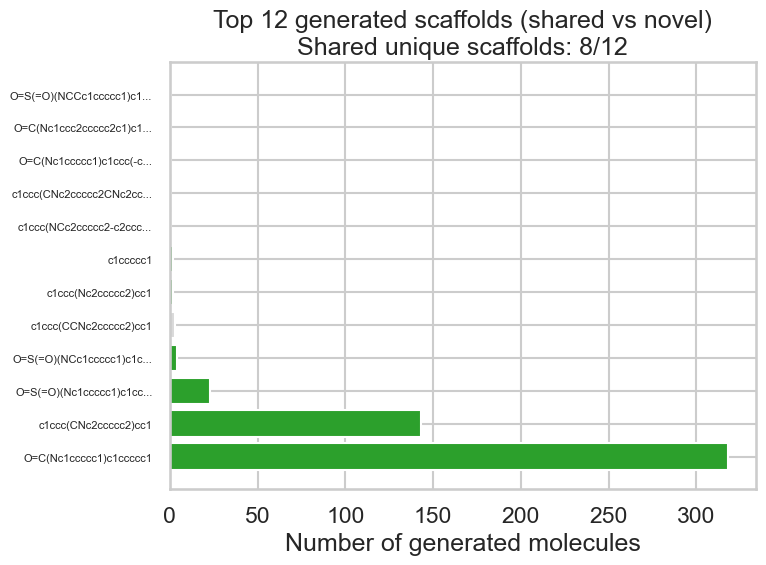

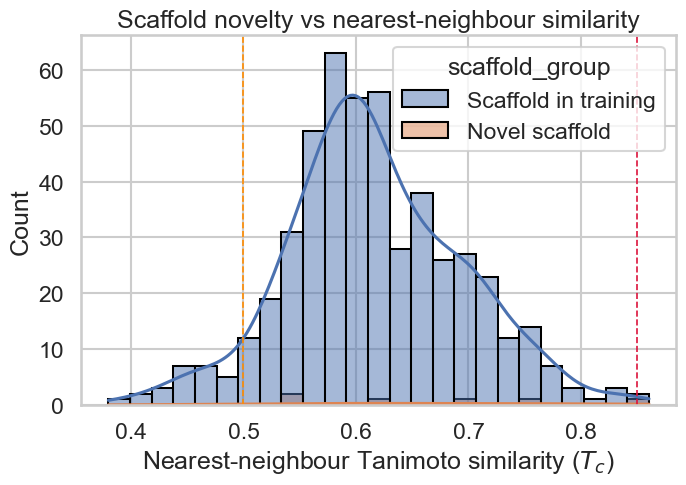

Saved:
  - chemical_space_outputs\full_The_prioritized_generated_compounds_nearest_neighbour_similarity.csv
  - chemical_space_outputs\full_The_prioritized_generated_compounds_similarity_summary.csv
  - chemical_space_outputs\full_The_prioritized_generated_compounds_scaffold_overlap.csv
  - chemical_space_outputs\full_The_prioritized_generated_compounds_top_scaffolds.png
  - chemical_space_outputs\full_The_prioritized_generated_compounds_scaffold_novelty_vs_Tc.png


In [40]:
batch_label = GEN_CSV.stem
batch_prefix = _safe_slug(f"full_{batch_label}")

full_results = analyze_compound_set(
    gen_df.copy(),
    set_label=f"full set ({batch_label})",
    file_prefix=batch_prefix,
    show_structure_grid=False,
)



## 5. Top-N most active compounds

Focused analysis of the **TOP_N** compounds with the highest predicted pIC50, including the structure grid.



ANALYSIS: top 3 by predicted pIC50
n compounds: 3
Mean max Tc:   0.6449 ± 0.1650
Median max Tc: 0.5750  (IQR 0.5507–0.7042)
Range:         [0.5263, 0.8333]
Exact SMILES overlap with training set: 0
Bemis-Murcko scaffolds: train=1131, generated=2, shared=2 (100.0% of generated unique scaffolds)
Shared-scaffold molecule coverage: 100.0%
Predicted pIC50: 7.250 ± 0.017 [7.24, 7.27]
Pearson r(predicted pIC50, max Tc) = 0.932


,class,n,percent
0,close analogue (Tc >= 0.85),0,0.00
1,related (0.50 <= Tc < 0.85),3,100.00
2,distant (Tc < 0.50),0,0.00


,No.,canonical_smiles,predicted_pIC50,max_Tc,interpolation_class,nn1_chembl_id,nn1_Tc,nn1_pchembl,nn1_smiles
0,1,O=C(NO)c1cccc(NS(=O)(=O)c2ccccc2)c1,7.2693,0.833333,related (0.50 <= Tc < 0.85),CHEMBL4206936,0.833333,7.30,O=C(NO)c1cccc(S(=O)(=O)Nc2ccccc2)c1
1,2,O=C(NO)c1ccc(NC(=O)c2ccc(Br)cc2Br)cc1,7.2443,0.526316,related (0.50 <= Tc < 0.85),CHEMBL4757957,0.526316,7.67,Cc1ccc(C(=O)Nc2ccc(C(=O)NO)cc2)cc1
2,3,O=C(NO)c1ccc(NC(=O)c2cc(Br)cc(Br)c2F)cc1,7.2368,0.575000,related (0.50 <= Tc < 0.85),CHEMBL4750701,0.575000,7.85,O=C(NO)c1ccc(NC(=O)c2c(F)c(F)c(F)c(F)c2F)cc1


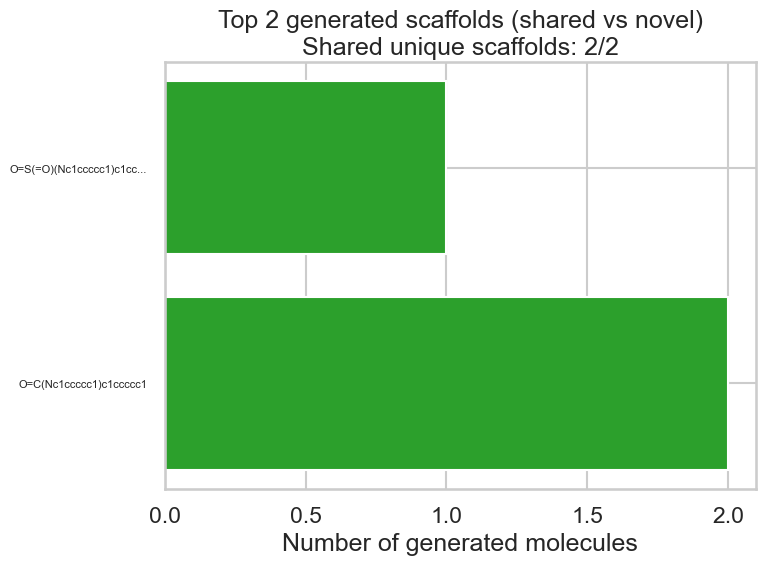

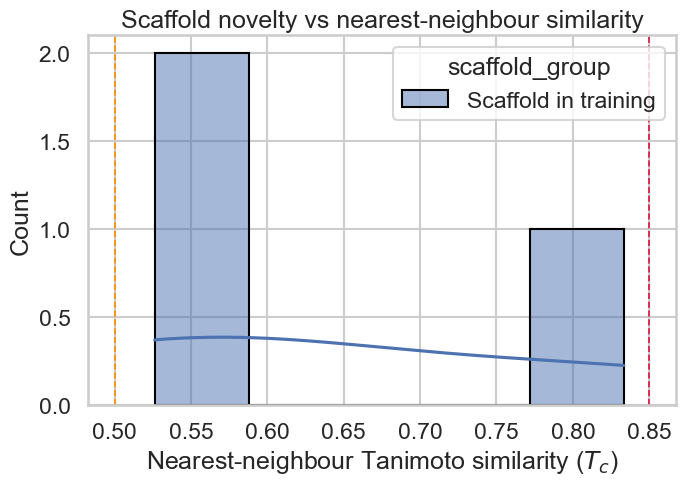

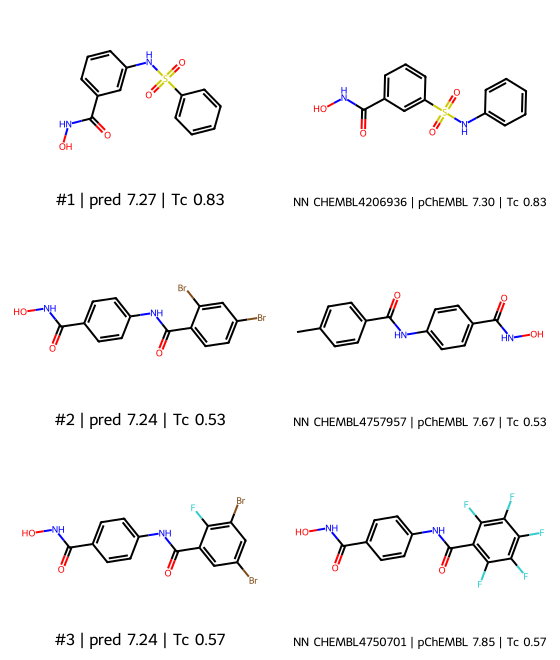

Saved:
  - chemical_space_outputs\top3_The_prioritized_generated_compounds_nearest_neighbour_similarity.csv
  - chemical_space_outputs\top3_The_prioritized_generated_compounds_similarity_summary.csv
  - chemical_space_outputs\top3_The_prioritized_generated_compounds_scaffold_overlap.csv
  - chemical_space_outputs\top3_The_prioritized_generated_compounds_top_scaffolds.png
  - chemical_space_outputs\top3_The_prioritized_generated_compounds_scaffold_novelty_vs_Tc.png
  - chemical_space_outputs\top3_The_prioritized_generated_compounds_nn_example_pairs.png


In [41]:
top_label = f"top {TOP_N} by predicted pIC50"
top_prefix = _safe_slug(f"top{TOP_N}_{batch_label}")

top_results = analyze_compound_set(
    top_df.copy(),
    set_label=top_label,
    file_prefix=top_prefix,
    show_structure_grid=True,
)



## 6. Manuscript figures

1. **Distribution of nearest-neighbour $T_c$** — full prioritised set (500 compounds).
2. **Combined UMAP** — panel A: full set (uniform colour); panel B: top-N compounds (colour key in legend).



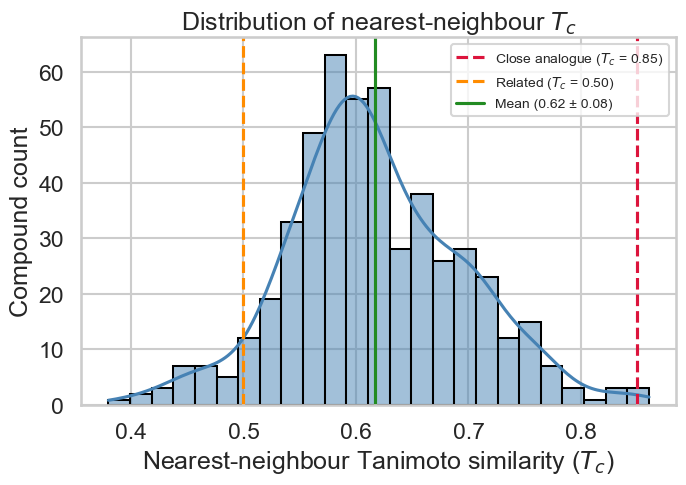

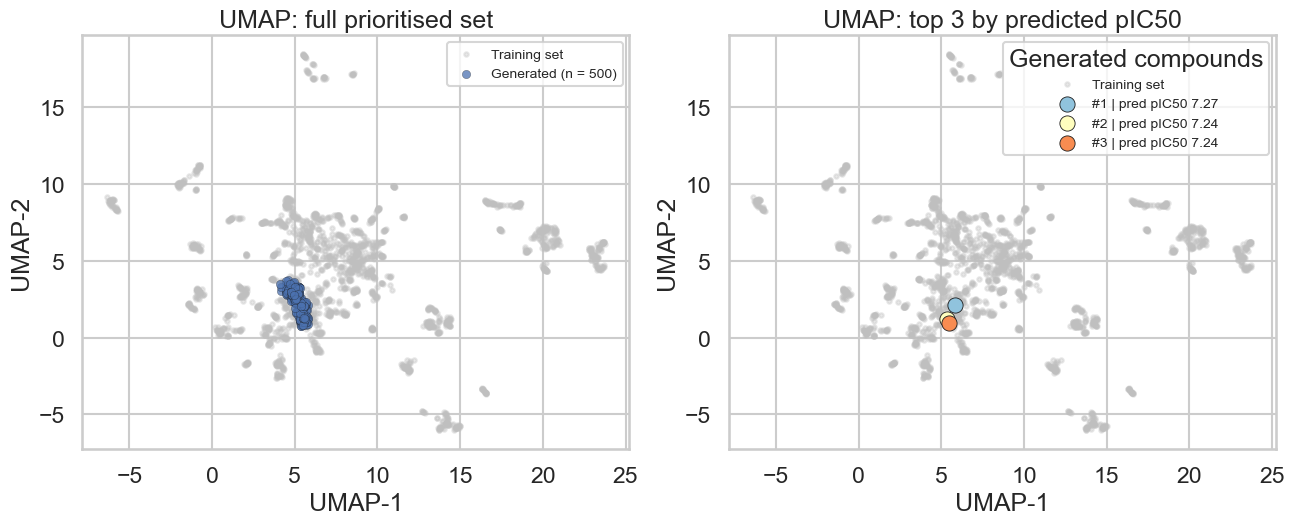

Figure files saved:
  - chemical_space_outputs\The_prioritized_generated_compounds_nn_similarity_distribution.png
  - chemical_space_outputs\The_prioritized_generated_compounds_umap_full_and_top.png
  - chemical_space_outputs\top3_The_prioritized_generated_compounds_nn_example_pairs.png


In [42]:
fig_prefix = _safe_slug(batch_label)

plot_tanimoto_distribution(
    full_results["nn_df"],
    full_results["mean_tc"],
    full_results["std_tc"],
    OUT_DIR / f"{fig_prefix}_nn_similarity_distribution.png",
)

plot_combined_umap(
    full_results["gen_umap"],
    top_results["gen_umap"],
    top_results["nn_df"],
    OUT_DIR / f"{fig_prefix}_umap_full_and_top.png",
    n_full=len(full_results["nn_df"]),
)

print("Figure files saved:")
print(f"  - {OUT_DIR / f'{fig_prefix}_nn_similarity_distribution.png'}")
print(f"  - {OUT_DIR / f'{fig_prefix}_umap_full_and_top.png'}")
print(f"  - {OUT_DIR / f'{top_prefix}_nn_example_pairs.png'}")

